<a href="https://colab.research.google.com/github/admpvlck/PyTorch/blob/Linear-Regression/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [237]:
#Importovanie knižníc, ktoré budeme používať
#Importing libraries that we will use
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd

#Generovanie syntetických dát (X)
#Generating synthetic data (X)
m2=torch.randint(20, 120, (100, 1), dtype=torch.float32)
rooms=torch.randint(1, 5, (100, 1), dtype=torch.float32)
floor=torch.randint(0, 11, (100, 1), dtype=torch.float32)
dist=torch.randint(0, 21, (100, 1), dtype=torch.float32)

#Vytvorenie tensoru so 4 stĺpcami (shape:[100, 4])
#dim=1 - spájanie po stĺpcoch; dim=0 - spájanie po riadkoch
#Creating a tensor with 4 columns (shape: [100, 4])
#dim=1 - concatenate along columns; dim=0 - concatenate along rows
X=torch.cat([m2, rooms, floor, dist], dim=1)
X.shape

torch.Size([100, 4])

In [238]:
#Definovanie weights jednotlivým premenným (budeme predikovať teoretickú cenu bytu a náklady)
#Defining weights for each variable (we will predict the theoretical apartment price and costs)
true_w=torch.tensor([[5, 10, 2, -0.5],
                    [1, 2, 1, -0.2]])

#Definovanie bias (základné hodnoty y, ak by vstupy boli nulové)
#Defining bias (baseline values of y if inputs were zero)
true_b=torch.tensor([50, 100])

#Generovanie syntetických dát (y)
#Generating synthetic data (y)
y=torch.mm(X, true_w.T)+true_b

#Pridanie šumu k dátam
#Adding noise to the data
y+=torch.randn(100, 2, dtype=torch.float32)*5

In [239]:
#Číslo určujúce hranice na delenie dát na trénovaciu a testovaciu množinu
#Number determining the split between training and test datasets
split_int=int(0.8*len(X))

#Trénovacia množina
#Training dataset
train_X=X[0:split_int]
train_y=y[0:split_int]

#Testovacia množina
#Test dataset
test_X=X[split_int:len(X)]
test_y=y[split_int:len(y)]

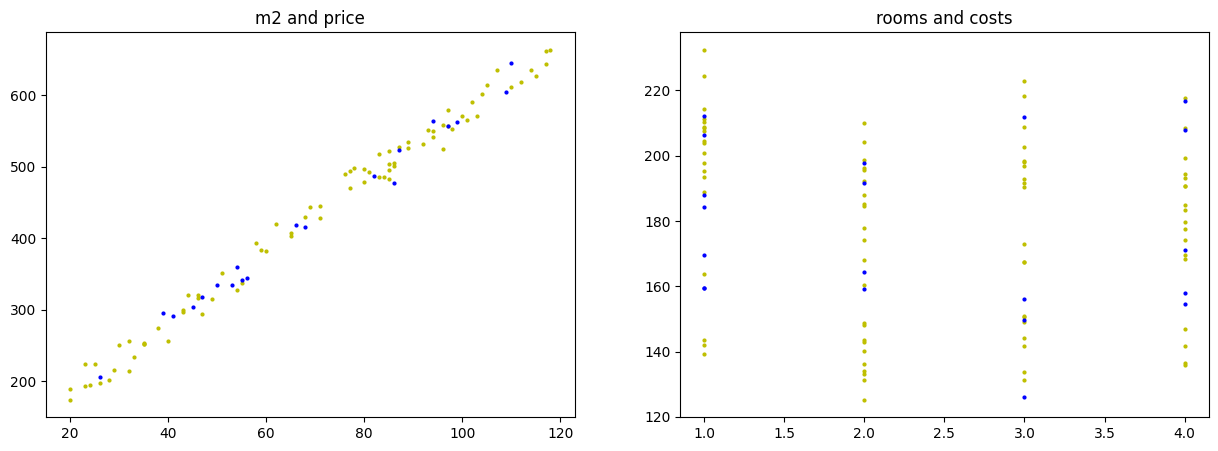

In [240]:
#Znázornenie niektorých vzťahov medzi X a y
#Visualization of some relationships between X and y
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(train_X[:, 0], train_y[:, 0], c='y', s=4)
plt.scatter(test_X[:, 0], test_y[:, 0], c='b', s=4)
plt.title('m2 and price')

plt.subplot(1, 2, 2)
plt.scatter(train_X[:, 1], train_y[:, 1], c='y', s=4)
plt.scatter(test_X[:, 1], test_y[:, 1], c='b', s=4)
plt.title('rooms and costs')

plt.show()

In [241]:
#Tvorba modelu
#Creating the model
class LinearRegressionModel(nn.Module):
  def __init__(self, in_shape, out_shape):
    super().__init__()

    self.linear=nn.Linear(in_features=in_shape, out_features=out_shape)

  def forward(self, x):
    out=self.linear(x)
    return out

#in_shape - počet stĺpcov X; out_shape - počet predikovaných hodnôt
#in_shape - number of columns in X; out_shape - number of predicted values
model=LinearRegressionModel(4, 2)

In [242]:
#Definovanie loss funkcie a opimizer
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model.parameters(),
                          lr=0.001)

In [243]:
#Trénovanie a testovanie modelu
#Defining the loss function and optimizer
epochs=50000

model_results={
    'epoch':[],
    'train_loss':[],
    'test_loss':[]
}

for epoch in range(0, epochs+1):
  model.train()

  train_y_pred=model(train_X)
  train_loss=loss_fn(train_y_pred, train_y)

  model_results['epoch'].append(epoch)
  model_results['train_loss'].append(train_loss.item())

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model.eval()

  with torch.inference_mode():
    test_y_pred=model(test_X)
    test_loss=loss_fn(test_y_pred, test_y)

    model_results['test_loss'].append(test_loss.item())

  if epoch%1000==0:
    print('Epoch: {a}; Train loss: {b:.2f}; Test loss: {c:.2f}'.format(a=epoch, b=train_loss, c=test_loss))

Epoch: 0; Train loss: 297.65; Test loss: 289.39
Epoch: 1000; Train loss: 27.59; Test loss: 24.55
Epoch: 2000; Train loss: 24.55; Test loss: 22.75
Epoch: 3000; Train loss: 22.77; Test loss: 20.94
Epoch: 4000; Train loss: 21.53; Test loss: 19.01
Epoch: 5000; Train loss: 20.51; Test loss: 18.07
Epoch: 6000; Train loss: 19.61; Test loss: 16.93
Epoch: 7000; Train loss: 18.91; Test loss: 16.41
Epoch: 8000; Train loss: 18.32; Test loss: 15.72
Epoch: 9000; Train loss: 17.85; Test loss: 15.12
Epoch: 10000; Train loss: 17.43; Test loss: 14.57
Epoch: 11000; Train loss: 17.08; Test loss: 14.20
Epoch: 12000; Train loss: 16.74; Test loss: 13.83
Epoch: 13000; Train loss: 16.40; Test loss: 13.52
Epoch: 14000; Train loss: 16.08; Test loss: 13.33
Epoch: 15000; Train loss: 15.78; Test loss: 12.97
Epoch: 16000; Train loss: 15.48; Test loss: 12.67
Epoch: 17000; Train loss: 15.20; Test loss: 12.50
Epoch: 18000; Train loss: 14.93; Test loss: 12.36
Epoch: 19000; Train loss: 14.69; Test loss: 12.30
Epoch: 2000

In [244]:
#Predikcia y pomocou natrénovaného modelu
#Predicting y using the trained model
model.eval()

with torch.inference_mode():
  y_pred=model(test_X)

In [246]:
#Vytvorenie dataframe pre porovnanie predikcie so skutočnými hodnotami
#Creating a dataframe to compare predictions with actual values
comp_df=pd.DataFrame({
    'price_true':test_y[:, 0],
    'price_prediction':y_pred[:, 0],
    'costs_true':test_y[:, 1],
    'costs_prediction':y_pred[:, 1]
})

comp_df

,price_true,price_prediction,costs_true,costs_prediction
0,290.799316,278.738617,149.624817,125.607918
1,296.020081,284.373383,154.582474,138.106216
2,415.084167,407.711548,187.922501,166.105392
3,318.183258,317.095978,156.172256,154.641861
4,557.634705,559.735962,206.345276,217.317749
5,303.693878,288.553223,159.447144,137.837738
6,563.324890,575.203308,207.995071,221.661240
7,344.263062,335.502167,164.333160,141.705811
8,341.772522,335.314972,169.607971,154.114029
9,206.192169,202.196014,126.088234,111.980827


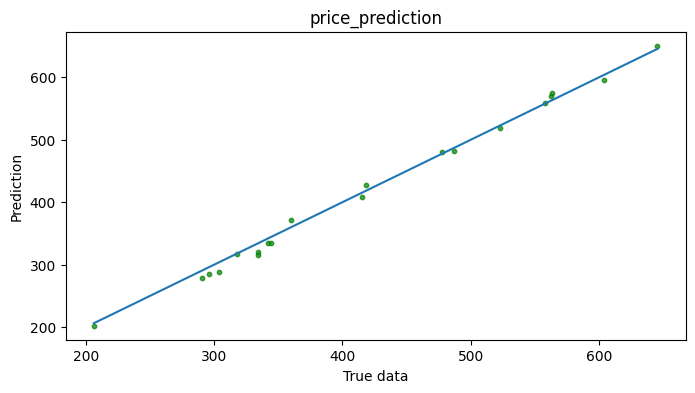

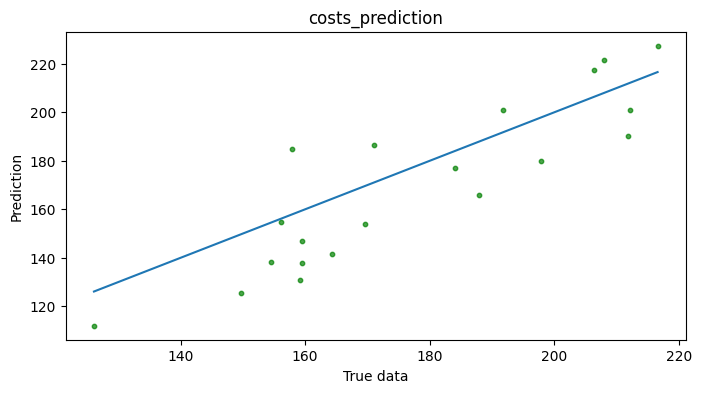

In [247]:
#Grafické znázornenie výsledkov (1)
#Graphical visualization of results (1)
#True data vs Prediction
for i, label in enumerate(['price_prediction', 'costs_prediction']):
  plt.figure(figsize=(8, 4))

  plt.scatter(test_y[:, i], y_pred[:, i], alpha=0.7, s=10, c='green')
  plt.plot([test_y[:, i].min(), test_y[:, i].max()],
           [test_y[:, i].min(), test_y[:, i].max()])
  plt.title(label)
  plt.xlabel('True data')
  plt.ylabel('Prediction')
  plt.show()

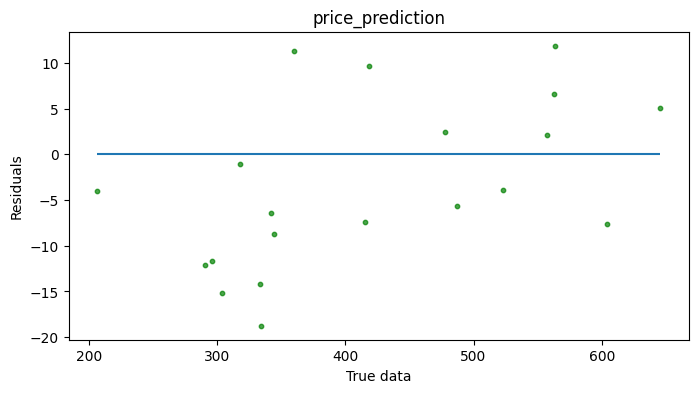

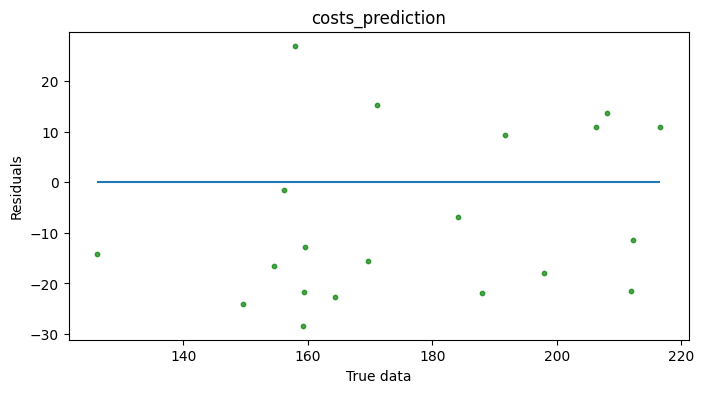

In [248]:
#Grafické znázornenie výsledkov (2)
#Graphical visualization of results (2)
#Residuals
for i, label in enumerate(['price_prediction', 'costs_prediction']):
  plt.figure(figsize=(8, 4))
  residuals=y_pred[:, i]-test_y[:, i]

  plt.scatter(test_y[:, i], residuals, alpha=0.7, s=10, c='green')
  plt.hlines(0, min(test_y[:, i]), max(test_y[:, i]))
  plt.title(label)
  plt.xlabel('True data')
  plt.ylabel('Residuals')
  plt.show()

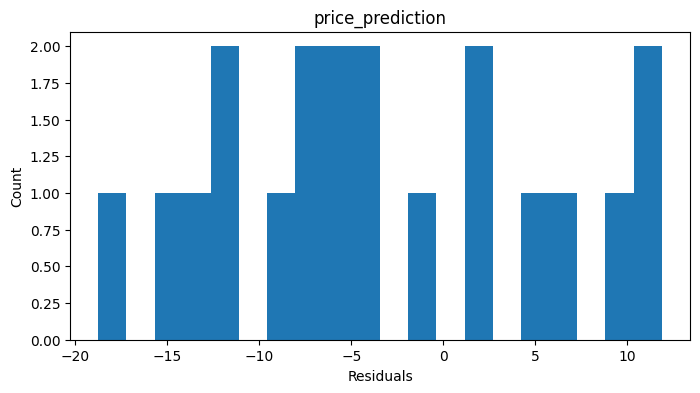

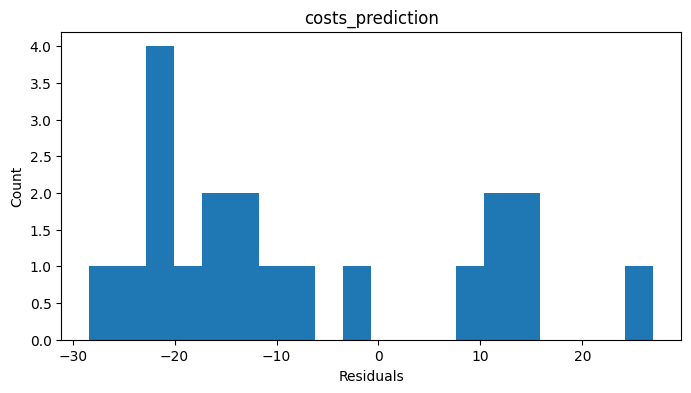

In [249]:
#Grafické znázornenie výsledkov (3)
#Graphical visualization of results (3)
#Histogram - residuals
for i, label in enumerate(['price_prediction', 'costs_prediction']):
  plt.figure(figsize=(8, 4))
  residuals=y_pred[:, i]-test_y[:, i]

  plt.hist(residuals, bins=20)
  plt.title(label)
  plt.xlabel('Residuals')
  plt.ylabel('Count')

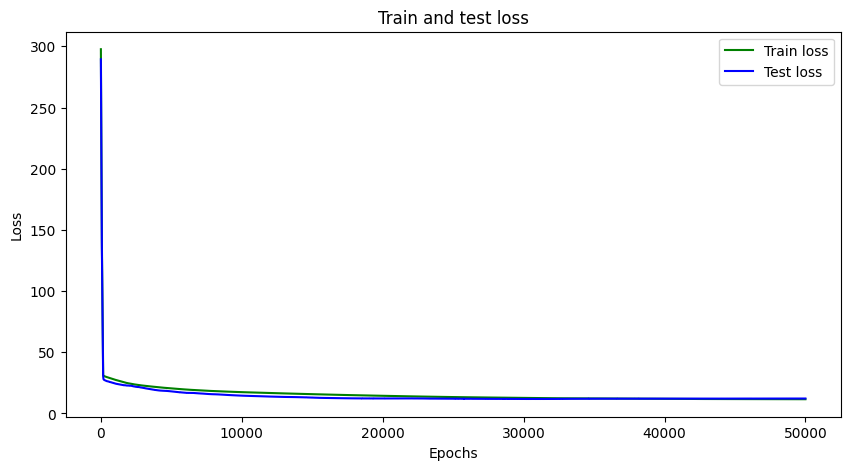

In [253]:
#Grafické znázornenie výsledkov (4)
#Graphical visualization of results (4)
#Train loss, test loss
plt.figure(figsize=(10, 5))

plt.plot(model_results['epoch'], model_results['train_loss'], label='Train loss', c='green')
plt.plot(model_results['epoch'], model_results['test_loss'], label='Test loss', c='blue')
plt.legend(loc='best')
plt.title('Train and test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()